In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

from sklearn.metrics import roc_auc_score, average_precision_score

In [26]:
tapogee_predictions = pd.read_csv("../checkpoints/tAPOGEE_predictions.csv", sep="\t", index_col="Mithril_id")
tapogee_predictions

,Start,Ref,Alt,Gene_symbol,gene.position,tAPOGEE_score,tAPOGEE_oob_score,tAPOGEE_posterior,category
Mithril_id,,,,,,,,,
MITHRIL.1728,577,G,A,MT-TF,1,0.780641,0.780641,0.994751,pathogenic
MITHRIL.1729,577,G,C,MT-TF,1,0.703568,0.703568,0.951709,likely pathogenic
MITHRIL.1730,577,G,T,MT-TF,1,0.767472,0.767472,0.991911,pathogenic
MITHRIL.1731,578,T,A,MT-TF,2,0.520965,0.520965,0.320783,VUS
MITHRIL.1732,578,T,C,MT-TF,2,0.632326,0.632326,0.791225,VUS
...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,16022,T,C,MT-TP,2,0.665709,0.665709,0.887440,VUS
MITHRIL.48240,16022,T,G,MT-TP,2,0.773280,0.773280,0.993295,pathogenic
MITHRIL.48241,16023,G,A,MT-TP,1,0.841406,0.834604,0.999351,pathogenic


In [27]:
pon_predictions = pd.read_csv('./PON_data/PON_predictions.txt', sep="\t").set_index(["Start", "Ref", "Alt"])
pon_predictions = pd.read_csv("../data/mithril_V03.txt", sep="\t", low_memory=False)[["Start", "Ref", "Alt", "Mithril_id"]].merge(
    pon_predictions, left_on=["Start", "Ref", "Alt"], right_index=True
).set_index("Mithril_id").loc[tapogee_predictions.index]
pon_predictions

,Start,Ref,Alt,aa,Classification,ML_probability_of_pathogenicity,Prediction_of_Kondrashov_method
Mithril_id,,,,,,,
MITHRIL.1728,577,G,A,Phe,Pathogenic,0.934854,1.0
MITHRIL.1729,577,G,C,Phe,Pathogenic,0.934854,1.0
MITHRIL.1730,577,G,T,Phe,Pathogenic,0.934854,1.0
MITHRIL.1731,578,T,A,Phe,Likely pathogenic,0.520981,1.0
MITHRIL.1732,578,T,C,Phe,Likely pathogenic,0.520981,1.0
...,...,...,...,...,...,...,...
MITHRIL.48239,16022,T,C,Pro,Pathogenic,0.699696,1.0
MITHRIL.48240,16022,T,G,Pro,Pathogenic,0.699696,1.0
MITHRIL.48241,16023,G,A,Pro,Pathogenic,0.804488,1.0


In [28]:
pon_classes = ["Neutral", "Likely neutral", "Likely pathogenic", "Pathogenic"]
pon_classes

['Neutral', 'Likely neutral', 'Likely pathogenic', 'Pathogenic']

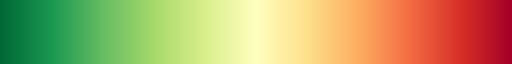

In [29]:
cmap = cm.RdYlGn_r
cmap

/tmp/ipykernel_2607182/2447666262.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pon_predictions.groupby("Classification").apply(


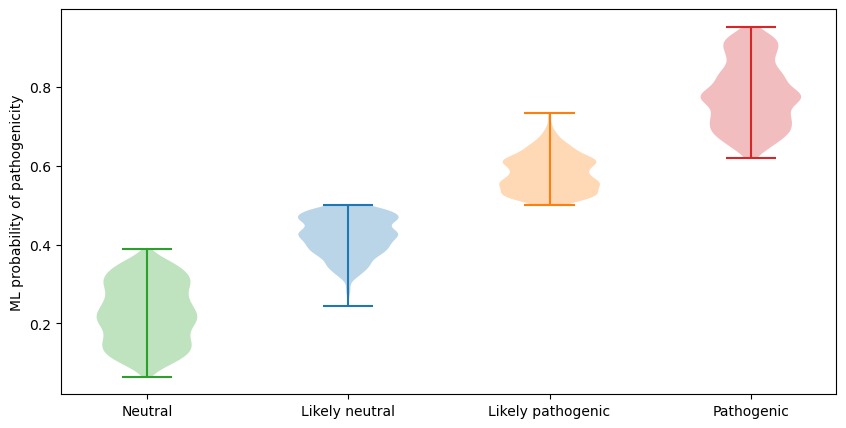

In [30]:
plt.figure(figsize=(10,5))

pon_predictions.groupby("Classification").apply(
    lambda x: plt.violinplot(
        x.ML_probability_of_pathogenicity,
        positions=(pon_classes.index(x.name), ),
    )
)
plt.xticks(range(len(pon_classes)), pon_classes)
plt.ylabel("ML probability of pathogenicity")
plt.show()

In [31]:
pon_training_set = pd.read_csv("./PON_data/PON_training_set.txt", sep="\t").merge(
    pd.read_csv("../data/mithril_V03.txt", sep="\t"),
    on=["Start", "Ref", "Alt"], how="left"
)[["Start", "Ref", "Alt", "Mithril_id", "label"]]

# variants not matched are annotated as complement in PON so:
pon_training_set.loc[pon_training_set.Mithril_id.isna()] = pon_training_set.loc[pon_training_set.Mithril_id.isna()].apply(
    lambda row:
        row.replace({"A": "T", "T": "A", "C": "G", "G": "C"}),
    axis=1
)

pon_training_set = pon_training_set[["Start", "Ref", "Alt", "label"]].merge(
    pd.read_csv("../data/mithril_V03.txt", sep="\t"),
    on=["Start", "Ref", "Alt"], how="left"
)[["Start", "Ref", "Alt", "Mithril_id", "label"]].set_index("Mithril_id")

pon_training_set

,Start,Ref,Alt,label
Mithril_id,,,,
MITHRIL.1744,582,T,C,1
MITHRIL.1746,583,G,A,1
MITHRIL.1755,586,G,A,1
MITHRIL.1822,608,A,G,0
MITHRIL.1830,611,G,A,1
...,...,...,...,...
MITHRIL.48026,15951,A,G,0
MITHRIL.48068,15965,A,G,0
MITHRIL.48073,15967,G,A,1


In [32]:
y = pd.read_csv("../data/training_set.txt", sep="\t", index_col="Mithril_id").label\
    .replace(["benign", "pathogenic"], [0,1])
y

/tmp/ipykernel_2607182/3734481475.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(["benign", "pathogenic"], [0,1])


Mithril_id
MITHRIL.1744     1
MITHRIL.1753     0
MITHRIL.1770     0
MITHRIL.1772     1
MITHRIL.1773     0
                ..
MITHRIL.48225    0
MITHRIL.48227    0
MITHRIL.48229    0
MITHRIL.48243    0
MITHRIL.48241    1
Name: label, Length: 684, dtype: int64

In [33]:
y_test = pd.read_csv("../data/test_set.txt", sep="\t", index_col="Mithril_id").label\
    .replace(["Pathogenic", "Likely pathogenic", "Benign", "Likely benign"], [1,1,0,0])
y_test

/tmp/ipykernel_2607182/908432659.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(["Pathogenic", "Likely pathogenic", "Benign", "Likely benign"], [1,1,0,0])


Mithril_id
MITHRIL.1846     1
MITHRIL.4929     1
MITHRIL.9729     1
MITHRIL.9728     1
MITHRIL.9752     1
                ..
MITHRIL.17470    0
MITHRIL.17540    0
MITHRIL.30284    0
MITHRIL.44252    0
MITHRIL.47953    0
Name: label, Length: 71, dtype: int64

In [34]:
# labelled variants from our test set (Dataset 3 and 4) not present in the PON training set
y_unbiased = y_test.loc[y_test.index.difference(pon_training_set.index)]
y_unbiased

Mithril_id
MITHRIL.12936    0
MITHRIL.13118    0
MITHRIL.13364    0
MITHRIL.16812    0
MITHRIL.16818    0
MITHRIL.16908    0
MITHRIL.17078    1
MITHRIL.17141    0
MITHRIL.17326    0
MITHRIL.22440    0
MITHRIL.22541    1
MITHRIL.22573    0
MITHRIL.25030    1
MITHRIL.30245    0
MITHRIL.30254    0
MITHRIL.31541    0
MITHRIL.36689    0
MITHRIL.36776    1
MITHRIL.36891    0
MITHRIL.36917    0
MITHRIL.44195    1
MITHRIL.47886    0
MITHRIL.47888    0
MITHRIL.47894    0
MITHRIL.47942    1
MITHRIL.47962    0
MITHRIL.47996    0
MITHRIL.48108    0
MITHRIL.4929     1
MITHRIL.9872     1
MITHRIL.9909     1
Name: label, dtype: int64

In [35]:
len(y_unbiased), y_unbiased.sum()

(31, np.int64(9))

In [36]:
y_unbiased.mean()

np.float64(0.2903225806451613)

In [37]:
(
    roc_auc_score(y_unbiased, tapogee_predictions.loc[y_unbiased.index, "tAPOGEE_oob_score"]),
    roc_auc_score(y_unbiased, pon_predictions.loc[y_unbiased.index, "ML_probability_of_pathogenicity"]),
)

(np.float64(0.9242424242424242), np.float64(0.803030303030303))

In [38]:
(
    average_precision_score(y_unbiased, tapogee_predictions.loc[y_unbiased.index, "tAPOGEE_oob_score"]),
    average_precision_score(y_unbiased, pon_predictions.loc[y_unbiased.index, "ML_probability_of_pathogenicity"]),
)

(np.float64(0.9305555555555556), np.float64(0.7624007613254926))

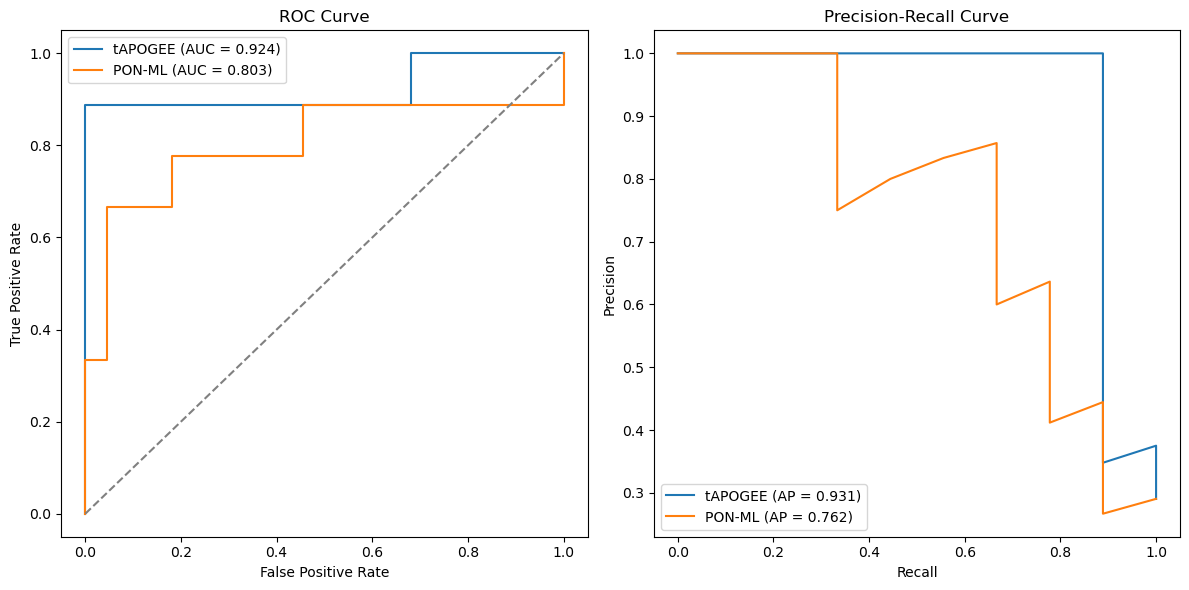

In [39]:
# Define models and their predictions
from sklearn.metrics import precision_recall_curve, roc_curve


models = {
    "tAPOGEE": tapogee_predictions.loc[y_unbiased.index, "tAPOGEE_oob_score"],
    "PON-ML": pon_predictions.loc[y_unbiased.index, "ML_probability_of_pathogenicity"],
}

# Plot ROC Curve
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for name, scores in models.items():
    fpr, tpr, _ = roc_curve(y_unbiased, scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_unbiased, scores):.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

# Plot Precision-Recall Curve
plt.subplot(1, 2, 2)
for name, scores in models.items():
    precision, recall, _ = precision_recall_curve(y_unbiased, scores)
    plt.plot(recall, precision, label=f"{name} (AP = {average_precision_score(y_unbiased, scores):.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.tight_layout()
plt.show()



In [40]:
mithril_features = pd.read_csv("../checkpoints/mithril_features.csv", sep="\t", index_col="Mithril_id")
mithril_features

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,Human_MSA_position,bulge,stem,hairpin,loop,unpaired_frequency,closest_modification,closest_modification_2D,OEUF_score
Mithril_id,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,1.000,3.724,0.117871,0.028169,3.8,0.832225,0.143385,1.0,0.769628,14.0,-0.802033,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1729,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.004435,1.0,0.769628,14.0,-5.816984,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1730,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.019956,1.0,0.769628,14.0,-3.647059,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1731,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.005174,1.0,1.096296,10.0,-5.594591,1,0,1,0,0,0.014503,7,7.0,0.358
MITHRIL.1732,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.477458,1.0,1.096296,10.0,0.933444,1,0,1,0,0,0.014503,7,7.0,0.358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,1.000,3.604,0.738729,0.000000,0.7,0.956554,0.023564,1.0,0.316291,14.0,-3.407268,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48240,1.000,3.604,0.738729,0.029412,4.7,0.956554,0.004418,1.0,0.316291,14.0,-5.822305,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48241,1.000,5.938,0.734021,0.000000,1.9,0.981591,0.012518,1.0,0.154686,14.0,-4.319805,0,0,1,0,0,0.003610,8,6.0,0.470


In [41]:
embedding = pd.read_csv("../data/Mithril_msm_embedding.csv", index_col=0)
embedding.index.name = "Mithril_id"
embedding.columns = "channel_"+embedding.columns.astype(str)
embedding

,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,channel_9,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,-0.046571,-0.464829,-1.071173,0.706031,0.254538,-0.839300,-0.785148,-0.686940,-0.066750,-0.083101,...,0.703984,-0.094465,0.001146,-0.474778,0.054920,0.746596,-0.846664,0.056164,0.580686,-0.568011
MITHRIL.1729,-0.094558,-0.843313,-0.774938,0.836958,-0.283595,-0.961378,-0.578084,-0.701949,0.039039,-0.158005,...,0.391420,-0.352180,0.091886,-0.714017,0.015839,0.481953,-0.791229,0.398780,0.376998,0.029397
MITHRIL.1730,0.050315,-0.794720,-0.958813,0.551639,-0.071321,-0.767290,-0.558026,-0.843187,0.249865,-0.380568,...,0.306507,-0.153325,0.306693,-0.223419,-0.042577,0.929070,-0.781954,0.641456,0.126171,0.083980
MITHRIL.1731,-0.271729,-0.401465,-0.722368,0.715860,-0.171587,-0.678559,-0.540892,-0.339579,-0.256668,-0.268223,...,0.985569,0.165077,-0.349262,-0.658368,-0.430892,-0.193119,-0.840392,-0.930292,0.894584,-0.970570
MITHRIL.1732,-0.189935,-0.290123,-0.115013,0.859563,-0.127386,-0.715655,-0.411798,-0.926073,-0.151554,-0.170612,...,1.006938,-0.278918,-0.724813,-0.523815,-0.416955,0.000319,-1.031683,-0.880209,1.119973,-0.960705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,0.085203,0.720789,0.258117,-0.241561,0.276256,0.001175,0.117050,-0.357717,0.238088,0.165467,...,-0.069218,0.467677,-0.082058,0.037380,0.941805,-0.044995,-0.369644,0.526498,-0.601754,-0.447180
MITHRIL.48240,-0.516000,0.442102,0.331330,0.229251,-0.081880,-0.531516,0.226194,-0.564276,0.209845,-0.133919,...,-0.124533,0.285401,-0.201929,-0.403190,0.809152,0.175132,-0.162785,0.336191,-0.763395,-0.056434
MITHRIL.48241,0.318094,0.357954,-0.837745,-0.545639,-0.157910,0.394076,-1.226594,-0.005673,0.406269,-0.306028,...,-0.098943,0.436399,0.025024,1.110456,-0.265077,0.567142,-0.822745,-0.657988,-0.763098,-0.291456


In [42]:
X = mithril_features.join(embedding)
X.shape

(4521, 788)

In [24]:
import pickle as pk
import sys, os

from sklearn import clone

sys.path.append(os.path.abspath(os.path.join(os.path.dirname("../"), os.pardir)))

# from CustomEstimators.PartialPCA import PartialPCA
# from CustomEstimators.FilterByCorrelation import FilterByCorrelation
# from CustomEstimators.GridSearchOOB_BinaryClassifier import GridSearchOOB_BinaryClassifier
# from CustomEstimators.DataFrameUtils import *
from customFunctions.utils import binary_auROC

tuned_model_svc = pk.load(open("../checkpoints/candidate_models/model_svc.pk", "rb"))
tuned_model_svc

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', '...
                                                                       scoring_function=<function roc_auc_score at 0x77984e0d67a0>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.04,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x77984db09580>, verbose=2)

In [25]:
# clone the model with its preprocessing hyperparameters
test_model = clone(tuned_model_svc.best_estimator_)

# the original 0.01 alpha discards all RNA-MSM channels, so we set it to a higher value
test_model["input_selection"].set_params(channel_selection__alpha=0.025)

# OOB grid search + training on PON training set
test_model.fit(X.loc[pon_training_set.index], pon_training_set.label)
test_model

/home/saldan/Desktop/projects/nAPOGEE/CustomEstimators/PartialPCA.py:38: UserWarning: WARNING: n_components > feature pca features. Setting n_components to 2.
  warnings.warn(f"WARNING: n_components > feature pca features. Setting n_components to {self.n_features_in_pca}.")


Pipeline(steps=[('input_selection',
                 ColumnTransformerDF(transformers=[('feature_selection',
                                                    SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                       random_state=777),
                                                                      threshold=0.01),
                                                    Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', 'ddG',
       'ref_frequency', 'alt_frequency', 'coverage', 'entropy',
       'conservation_blocks', 'PWM...
                 GridSearchOOB_BinaryClassifier(estimator=BalancedBaggingClassifier(estimator=SVC(C=100,
                                                                                                  gamma=0.001,
                                                                                                  probability=True),
                                                                                    max_features=0.75,
                                                                                    n_estimators=500,
                                                                                    n_jobs=-1,
                                                                                    oob_score=True,
                                                                                    replacement=True,
                                                                                    sampling_strategy='not '
                                                                                                      'minority'),
                                                n_jobs=-1,
                                                param_grid=<sklearn.model_selection._search.ParameterGrid object at 0x77984c8a9fd0>,
                                                scoring_function=<function roc_auc_score at 0x77984e0d67a0>))])

In [ ]:
# OOB AUC
test_model[-1].best_score

np.float64(0.8347652347652349)

In [32]:
(
    roc_auc_score(y_unbiased, test_model.predict_proba(X.loc[y_unbiased.index])[:, 1]),
    roc_auc_score(y_unbiased, pon_predictions.loc[y_unbiased.index, "ML_probability_of_pathogenicity"]),
)

(np.float64(0.898989898989899), np.float64(0.803030303030303))

In [33]:
(
    average_precision_score(y_unbiased, test_model.predict_proba(X.loc[y_unbiased.index])[:, 1]),
    average_precision_score(y_unbiased, pon_predictions.loc[y_unbiased.index, "ML_probability_of_pathogenicity"]),
)

(np.float64(0.8053723509605863), np.float64(0.7624007613254926))

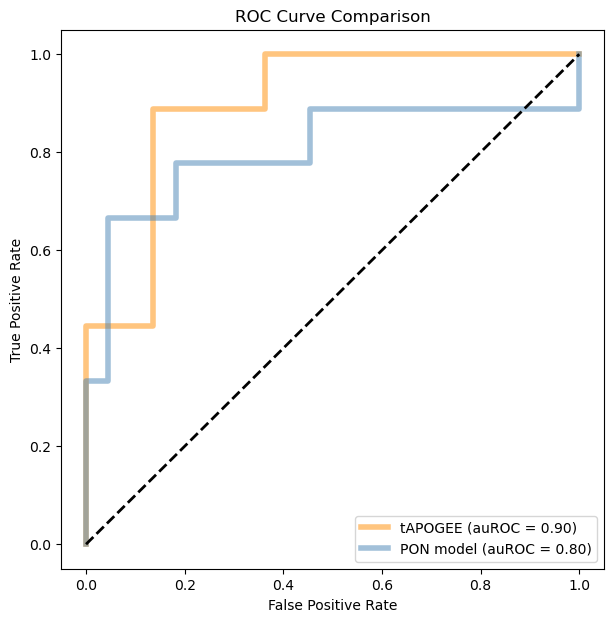

In [36]:
# Compute ROC curve and AUC for your model
fpr_model, tpr_model, _ = roc_curve(y_unbiased, test_model.predict_proba(X.loc[y_unbiased.index])[:, 1])
auc_model = roc_auc_score(y_unbiased, test_model.predict_proba(X.loc[y_unbiased.index])[:, 1])

# Compute ROC curve and AUC for PON predictions
fpr_pon, tpr_pon, _ = roc_curve(y_unbiased, pon_predictions.loc[y_unbiased.index, "ML_probability_of_pathogenicity"])
auc_pon = roc_auc_score(y_unbiased, pon_predictions.loc[y_unbiased.index, "ML_probability_of_pathogenicity"])

# Plotting
plt.figure(figsize=(7, 7))
plt.plot(fpr_model, tpr_model, label=f"tAPOGEE (auROC = {auc_model:.2f})", linewidth=4, alpha=0.5, color="darkorange")
plt.plot(fpr_pon, tpr_pon, label=f"PON model (auROC = {auc_pon:.2f})", linewidth=4, alpha=0.5, color="steelblue")
plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=2)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [46]:
pon_training_set.label

Mithril_id
MITHRIL.1744     1
MITHRIL.1746     1
MITHRIL.1755     1
MITHRIL.1822     0
MITHRIL.1830     1
                ..
MITHRIL.48026    0
MITHRIL.48068    0
MITHRIL.48073    1
MITHRIL.48144    1
MITHRIL.48157    0
Name: label, Length: 146, dtype: int64

In [44]:
y_test

Mithril_id
MITHRIL.1846     1
MITHRIL.4929     1
MITHRIL.9729     1
MITHRIL.9728     1
MITHRIL.9752     1
                ..
MITHRIL.17470    0
MITHRIL.17540    0
MITHRIL.30284    0
MITHRIL.44252    0
MITHRIL.47953    0
Name: label, Length: 71, dtype: int64

In [47]:
y

Mithril_id
MITHRIL.1744     1
MITHRIL.1753     0
MITHRIL.1770     0
MITHRIL.1772     1
MITHRIL.1773     0
                ..
MITHRIL.48225    0
MITHRIL.48227    0
MITHRIL.48229    0
MITHRIL.48243    0
MITHRIL.48241    1
Name: label, Length: 684, dtype: int64

In [70]:
# datasets 1 - 2 purged of the PON training set
y_unbiased_1_2 = y.loc[y.index.difference(pon_training_set.index)]
y_unbiased_1_2

Mithril_id
MITHRIL.12794    0
MITHRIL.12797    0
MITHRIL.12836    1
MITHRIL.12844    1
MITHRIL.12854    1
                ..
MITHRIL.9824     0
MITHRIL.9831     0
MITHRIL.9841     0
MITHRIL.9870     0
MITHRIL.9881     0
Name: label, Length: 652, dtype: int64

In [84]:
(y_unbiased_1_2.sum(), len(y_unbiased_1_2)-y_unbiased_1_2.sum())

(np.int64(101), np.int64(551))

In [85]:
len(y_unbiased_1_2)

652

In [61]:
# we try to train tAPOGEE on the PON training set
test_model.fit(X.loc[pon_training_set.index], pon_training_set.label)
test_model

Pipeline(steps=[('input_selection',
                 ColumnTransformerDF(transformers=[('feature_selection',
                                                    SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                       random_state=777),
                                                                      threshold=0.01),
                                                    Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', 'ddG',
       'ref_frequency', 'alt_frequency', 'coverage', 'entropy',
       'conservation_blocks', 'PWM...
                 GridSearchOOB_BinaryClassifier(estimator=BalancedBaggingClassifier(estimator=SVC(C=100,
                                                                                                  gamma=0.0001,
                                                                                                  probability=True),
                                                                                    n_estimators=500,
                                                                                    n_jobs=-1,
                                                                                    oob_score=True,
                                                                                    replacement=True,
                                                                                    sampling_strategy='not '
                                                                                                      'minority'),
                                                n_jobs=-1,
                                                param_grid=<sklearn.model_selection._search.ParameterGrid object at 0x7cbbb9d34e10>,
                                                scoring_function=<function roc_auc_score at 0x7cbbbf5c68e0>))])

In [71]:
(
    roc_auc_score(y_unbiased_1_2, test_model.predict_proba(X.loc[y_unbiased_1_2.index])[:, 1]),
    roc_auc_score(y_unbiased_1_2, pon_predictions.loc[y_unbiased_1_2.index, "ML_probability_of_pathogenicity"]),
)

(np.float64(0.791450288404521), np.float64(0.7638047833821494))

In [72]:
(
    average_precision_score(y_unbiased_1_2, test_model.predict_proba(X.loc[y_unbiased_1_2.index])[:, 1]),
    average_precision_score(y_unbiased_1_2, pon_predictions.loc[y_unbiased_1_2.index, "ML_probability_of_pathogenicity"]),
)

(np.float64(0.37211602427400037), np.float64(0.3802001423241161))

In [69]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

# 5-repeated 10-fold cross validation on training set (Dataset 1 and 2)
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=777)
training_cross_validation = cross_validate(
    test_model, X.loc[y.index], y, cv=kf,
    return_estimator=True, scoring=binary_auROC,
    error_score="raise", verbose=99
)
training_cross_validation

[CV] START .....................................................................
[CV] END ......................................., score=0.840 total time=  54.6s
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:   54.6s
[CV] START .....................................................................
[CV] END ......................................., score=0.781 total time=  54.3s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:  1.8min
[CV] START .....................................................................
[CV] END ......................................., score=0.777 total time=  54.8s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:  2.7min
[CV] START .....................................................................
[CV] END ......................................., score=0.809 total time=  57.1s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:  3.7min
[CV] START .....................................................................
[CV] END ..................

{'fit_time': array([54.48707271, 54.16059542, 54.62815166, 56.93673325, 55.51925707,
        55.13279915, 53.85699558, 54.44922566, 55.17948437, 55.86920357,
        54.44050169, 53.5418191 , 55.31470037, 55.15230012, 54.46679139,
        54.63825393, 54.8925786 , 54.98230982, 56.32443333, 54.93993568,
        54.59015632, 55.16645622, 55.6679163 , 56.01598382, 55.673985  ,
        54.77221823, 55.08817244, 54.84341168, 55.28946495, 54.50781274,
        54.24841285, 55.44308448, 55.60650921, 54.67792177, 55.32725525,
        54.92087078, 53.29514933, 55.02301025, 54.67911696, 54.5985918 ,
        53.71422529, 53.97342873, 54.92953825, 54.4042275 , 54.76360488,
        55.13907528, 54.82523799, 54.48674536, 54.13756156, 54.84720039]),
 'score_time': array([0.12287927, 0.12247515, 0.12294745, 0.13387871, 0.1170392 ,
        0.10754347, 0.13547516, 0.11881757, 0.12406588, 0.13819885,
        0.14357328, 0.12500072, 0.12950158, 0.1142242 , 0.13622284,
        0.13693023, 0.12238359, 0.1248

In [77]:
cv_df = pd.DataFrame()

for i, (estimator, (cv_train, cv_test)) in enumerate(zip(training_cross_validation["estimator"], kf.split( X.loc[y.index], y))):
    cv_test_ids = y.index[cv_test]
    cv_test_ids = cv_test_ids[cv_test_ids.isin(y_unbiased_1_2.index)] # we remove variants present in the mitotip training set from each test fold to have an unbiased evaluation
    cv_df.loc[i, "random_ap"] = y.loc[cv_test_ids].mean()
    cv_df.loc[i, "tPOGEE_auc"] = roc_auc_score(y.loc[cv_test_ids], estimator.predict_proba(X.loc[cv_test_ids])[:,1])
    cv_df.loc[i, "pon_auc"] = roc_auc_score(y.loc[cv_test_ids], pon_predictions.loc[cv_test_ids, "ML_probability_of_pathogenicity"])
    cv_df.loc[i, "tPOGEE_ap"] = average_precision_score(y.loc[cv_test_ids], estimator.predict_proba(X.loc[cv_test_ids])[:,1])
    cv_df.loc[i, "pon_ap"] = average_precision_score(y.loc[cv_test_ids], pon_predictions.loc[cv_test_ids, "ML_probability_of_pathogenicity"])

cv_df

,random_ap,tPOGEE_auc,pon_auc,tPOGEE_ap,pon_ap
0,0.153846,0.794545,0.774545,0.474128,0.458933
1,0.179104,0.763636,0.666667,0.493521,0.364355
2,0.151515,0.753571,0.779464,0.320623,0.494010
3,0.166667,0.790083,0.682645,0.415096,0.324559
4,0.179104,0.853030,0.838636,0.554081,0.444952
5,0.140625,0.761616,0.756566,0.319087,0.280930
6,0.126984,0.859091,0.809091,0.371916,0.499035
7,0.126984,0.811364,0.856818,0.410363,0.382817
8,0.140625,0.779798,0.725253,0.479209,0.446961
9,0.179104,0.906061,0.771212,0.645997,0.446118


In [78]:
cv_df.mean()

random_ap     0.154419
tPOGEE_auc    0.803647
pon_auc       0.764997
tPOGEE_ap     0.455618
pon_ap        0.430989
dtype: float64

In [75]:
from scipy import stats
stats.wilcoxon(cv_df.tPOGEE_auc, cv_df.pon_auc)

WilcoxonResult(statistic=np.float64(193.5), pvalue=np.float64(6.010637926934237e-06))

In [79]:
(cv_df.tPOGEE_auc - cv_df.pon_auc).mean()

np.float64(0.03864954313363404)

In [80]:
stats.wilcoxon(cv_df.tPOGEE_ap, cv_df.pon_ap)

WilcoxonResult(statistic=np.float64(463.0), pvalue=np.float64(0.0932040847757225))

In [82]:
(cv_df.tPOGEE_ap - cv_df.pon_ap).mean()

np.float64(0.024629031108885632)